# 21 · After sizing: trim, the conversion corridor and trajectories

Sizing works with quasi-steady points: hover, airplane-mode cruise, failure hovers. It never flies the **conversion** between them. That happens
after sizing, on the fixed aircraft, in `trajectory/` (768 lines):

- `trajectory/corridor.py`: level-flight **trim** at any nacelle angle and airspeed (thrust, attitude, tail deflection, disc tilt), and the
  **computed conversion corridor**: at each nacelle angle, the slowest and fastest speed at which a trim exists inside the limits;
- `trajectory/tiltrotor.py`: a point-mass tiltrotor model and a **direct-collocation** trajectory builder on AeroSandbox's point-mass dynamics,
  for problems like a minimum-energy transition or a minimum-time climb.

These are separate `asb.Opti` problems whose design quantities are all numbers. They never feed back into the sizing (the export and FE checks in
`export/openvsp` follow the same rule). This notebook covers both, on tutorial 19's near-reference design.

**In this notebook**
1. `TiltrotorPointMass`: forces and power at any attitude and nacelle angle.
2. Trim: four unknowns, three equations, least power; the limits.
3. The computed corridor, and what bounds it.
4. Direct collocation: states, controls and dynamics as Opti variables and constraints.
5. A minimum-energy transition and a minimum-time climb inside the computed corridor.

**Run time:** about 15 seconds (tutorial 19's design is loaded from the cache, or solved in about a minute).

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace
from examples.halo_sizing import HaloRequirements, HaloAssumptions, solve_halo_sizing
requirements = HaloRequirements()
reference = cached("reference_scholz", lambda: solve_halo_sizing(requirements, replace(HaloAssumptions(), aerodynamics_model="scholz")))
counts = {name: whole for name, (relaxed, whole) in reference.machine_units.items()}
assumptions = replace(HaloAssumptions(), aerodynamics_model="scholz", count_units_motor=counts["motor"],
                      count_units_generator=counts["generator"])
print(f"the sized aircraft: {lb(reference.mass_takeoff_kg):,.0f} lb, wing {reference.design.area_wing_m2:.1f} m2, rotor radius {reference.radius_rotor_m:.2f} m")

the sized aircraft: 15,134 lb, wing 23.2 m2, rotor radius 4.83 m


## 1. `TiltrotorPointMass`

An equation-only model of the sized aircraft (numeric `Aircraft` plus an aerodynamics model) in the longitudinal plane. At airspeed $V$, angle of
attack $\alpha$, nacelle angle $\tau$ (90° hover, 0° airplane), thrust per rotor $T$ and rotor speed $\Omega$:

$$F_x = nT(1 - f_\text{dl})\cos(\alpha + \tau) - D,\qquad F_z = -(nT(1 - f_\text{dl})\sin(\alpha + \tau) + L)$$

in wind axes. Rotor power uses the axial-flow `MomentumProfileRotor` with the velocity component along the rotor axis, $V\cos(\alpha + \tau)$ (the
edgewise component is ignored: no translational lift, a documented approximation). The airplane-mode rotor terms phase in with $\cos^2\tau$; the
download fades with $\sin^2\tau$ and with wake skew. It also evaluates the power chain (motors, generators, battery, fuel).

In [2]:
from aircraft_closure.trajectory.tiltrotor import TiltrotorPointMass
from examples.halo_sizing import build_halo_aircraft, build_halo_aerodynamics
model = TiltrotorPointMass(build_halo_aircraft(reference.design, requirements, assumptions), build_halo_aerodynamics(requirements, assumptions))
weight_N = reference.mass_takeoff_kg * 9.80665
for tilt_deg, velocity_m_s in ((90.0, 0.5), (60.0, 40.0), (0.0, 85.0)):
    f = model.evaluate(velocity_m_s, 0.0, 3.0, tilt_deg, thrust_per_rotor_N=weight_N / 2 * (1.07 if tilt_deg == 90 else 0.6 if tilt_deg == 60 else 0.12),
                       speed_rotor_rad_s=45.0)
    print(f"tilt {tilt_deg:4.0f} deg, {velocity_m_s:5.1f} m/s: lift {scalar(f.lift_N):8,.0f} N, drag {scalar(f.drag_N):6,.0f} N, "
          f"download {scalar(f.download_fraction):.3f}, rotor power {scalar(f.rotor.shaft_power_W) / 1e3:6.0f} kW")
print(f"airplane-mode stall speed at take-off mass: {model.velocity_stall_m_s(reference.mass_takeoff_kg) / u.knot:.0f} kt")

tilt   90 deg,   0.5 m/s: lift        2 N, drag      0 N, download 0.067, rotor power    646 kW
tilt   60 deg,  40.0 m/s: lift   12,656 N, drag  1,430 N, download 0.003, rotor power    537 kW
tilt    0 deg,  85.0 m/s: lift   56,698 N, drag  6,282 N, download 0.000, rotor power    506 kW
airplane-mode stall speed at take-off mass: 109 kt


## 2. Trim

`build_trim(opti, model, stability, geometry, limits, mass_kg, velocity_m_s, tilt_deg, altitude_m, speed_rotor_rad_s)`. In steady level flight the
forces along and normal to the velocity and the pitching moment about the CG vanish: **three equations**. The unknowns are thrust per rotor, attitude,
tail deflection and disc tilt (the tilt of the rotor tip-path plane from the shaft): **four**. The free one is spent on minimum rotor power. The moment
balance needs the CG and the hub positions (`TrimGeometry`); the rotor moment acts at the hub, a mast length from the nacelle spindle.

Every limit is a margin (`CorridorLimits`): attitude band, wing stall, ±25° ruddervator, disc-tilt authority (washing out toward airplane mode),
edgewise advance ratio ≤ 0.28 (the hub- and pylon-load proxy that bounds the XV-15 corridor at high nacelle angles), rotor power and blade loading,
a placard speed, and no inflow up through the disk.

In [3]:
from aircraft_closure.trajectory.corridor import solve_trim, solve_corridor, ComputedCorridor
from aircraft_closure.controls.stability import LongitudinalStability
from examples.halo_conversion_corridor import halo_corridor_case, tilts_deg
model_c, geometry, limits, speed_rotor_rad_s = halo_corridor_case(reference, requirements, assumptions)
print(geometry)
print(limits)
stability = LongitudinalStability()
common = dict(mass_kg=reference.mass_takeoff_kg, altitude_m=0.0, speed_rotor_rad_s=speed_rotor_rad_s)
for tilt_deg, velocity_kt in ((90.0, 40.0), (60.0, 100.0), (30.0, 150.0), (0.0, 180.0)):
    trim = solve_trim(model_c, stability, geometry, limits, velocity_m_s=velocity_kt * u.knot, tilt_deg=tilt_deg, **common)
    print(f"tilt {tilt_deg:4.0f}, {velocity_kt:5.0f} kt: pitch {trim.pitch_deg:5.1f} deg, tail {trim.deflection_tail_deg:6.1f} deg, "
          f"disc {trim.tilt_disc_deg:5.1f} deg, {trim.power_shaft_rotor_W / 1e3:5.0f} kW/rotor, CT/sigma {trim.blade_loading:.3f}, "
          f"mu_edge {trim.advance_ratio_edgewise:.2f}, binding {trim.binding()}")

TrimGeometry(x_cg_m=5.111290540691265, z_cg_m=0.7808248226910185, x_spindle_m=np.float64(5.111290540691265), z_spindle_m=1.2, length_mast_m=1.0)
CorridorLimits(pitch_min_deg=-5.0, pitch_max_deg=12.0, deflection_max_tail_deg=25.0, tilt_max_disc_deg=10.0, advance_ratio_edgewise_max=0.28, velocity_placard_m_s=118.83666666666669, blade_loading_max=None, power_shaft_max_rotor_W=None)


tilt   90,    40 kt: pitch   2.4 deg, tail  -25.0 deg, disc  -2.7 deg,   588 kW/rotor, CT/sigma 0.109, mu_edge 0.09, binding ('tail_deflection', 'inflow_through_disk')
tilt   60,   100 kt: pitch  10.8 deg, tail   -8.0 deg, disc   7.3 deg,   308 kW/rotor, CT/sigma 0.042, mu_edge 0.20, binding ()
tilt   30,   150 kt: pitch   5.6 deg, tail   -5.6 deg, disc   5.0 deg,   438 kW/rotor, CT/sigma 0.015, mu_edge 0.19, binding ('disc_tilt',)
tilt    0,   180 kt: pitch   3.3 deg, tail   -4.4 deg, disc   0.0 deg,   575 kW/rotor, CT/sigma 0.013, mu_edge 0.02, binding ()


## 3. The computed corridor

`solve_corridor_bound` makes the airspeed itself a variable and minimizes (low side) or maximizes (high side) it subject to the trim; the margins at
the bound name the limit that sets it. `solve_corridor` does that at each nacelle angle:

 tilt  low kt  set by                       high kt  set by
    0   120.3  pitch_max                      217.0  rotor_power
   15   117.7  pitch_max, disc_tilt           221.3  disc_tilt, rotor_power
   30   114.2  pitch_max, disc_tilt           229.3  disc_tilt, rotor_power
   45   108.2  pitch_max, disc_tilt           175.5  disc_tilt, edgewise_advance_ratio
   60    90.8  pitch_max, disc_tilt           143.8  disc_tilt, edgewise_advance_ratio
   75    -0.0  hover                          133.8  disc_tilt, edgewise_advance_ratio
   90    -0.0  hover                          129.9  disc_tilt, edgewise_advance_ratio


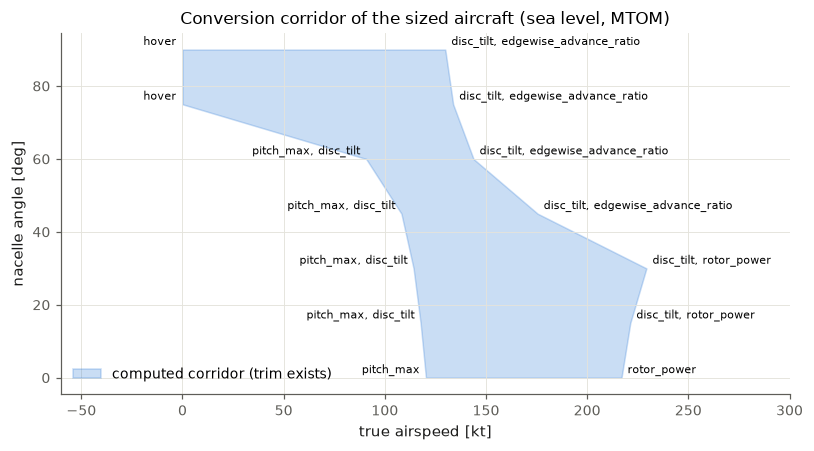

PASS  hover (zero speed) trims at 90 deg


In [4]:
with quiet_solver():
    bounds = solve_corridor(model_c, stability, geometry, limits, tilts_deg=tilts_deg, velocity_max_m_s=1.05 * limits.velocity_placard_m_s, **common)
print(f"{'tilt':>5} {'low kt':>7}  {'set by':<28} {'high kt':>7}  set by")
for low, high in bounds:
    text = lambda b: "-" if b.trim is None else f"{b.velocity_m_s / u.knot:7.1f}"
    print(f"{low.tilt_deg:5.0f} {text(low)}  {', '.join(low.binding):<28} {text(high)}  {', '.join(high.binding)}")
pairs = [(lo, hi) for lo, hi in bounds if lo.trim is not None and hi.trim is not None]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.fill_betweenx([lo.tilt_deg for lo, _ in pairs], [lo.velocity_m_s / u.knot for lo, _ in pairs], [hi.velocity_m_s / u.knot for _, hi in pairs],
                 color=blue, alpha=0.25, label="computed corridor (trim exists)")
for lo, hi in pairs:
    ax.annotate(", ".join(lo.binding), (lo.velocity_m_s / u.knot, lo.tilt_deg), xytext=(-4, 3), textcoords="offset points", ha="right", fontsize=7)
    ax.annotate(", ".join(hi.binding), (hi.velocity_m_s / u.knot, hi.tilt_deg), xytext=(4, 3), textcoords="offset points", fontsize=7)
ax.set(xlabel="true airspeed [kt]", ylabel="nacelle angle [deg]", xlim=(-60, 300), title="Conversion corridor of the sized aircraft (sea level, MTOM)")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()
check("hover (zero speed) trims at 90 deg", bounds[-1][0].trim is not None and bounds[-1][0].velocity_m_s < 0.1)

Reading it: the low-speed side away from hover is set by the **attitude limit** (with little nacelle tilt, forward thrust can only be cancelled by
drag or nose-up pitch) together with disc-tilt authority; the high-speed side is set by **edgewise advance ratio** at high nacelle angles and by **rotor
power** toward airplane mode. These are trim limits, not sizing constraints: if the corridor were unacceptable, the fix (more ruddervator, more disc
tilt, a different hub limit) would go back into the sizing as a new requirement.

## 4. Direct collocation

`build_tiltrotor_trajectory(opti, model, mass_initial_kg, soc_initial, count_nodes, duration_bounds_s, guess, limits, corridor)` creates, at every
node:

| States | Controls | Free |
|---|---|---|
| x, altitude, speed, flight-path angle (AeroSandbox `DynamicsPointMass2DSpeedGamma`), mass, SOC, bus energy | alpha, nacelle angle, thrust and speed per rotor, battery current, generator torque | final time |

The dynamics are imposed by trapezoidal collocation (`opti.constrain_derivative`, and AeroSandbox's `dynamics.constrain_derivatives`): each state's
change over an interval equals the interval-mean derivative times its duration. Fuel and SOC are integrated the same way. Path constraints at every node
mirror the sizing's margins: bus power balance, turboshaft power available, battery limits, rotor blade loading, tip Mach, advance ratio, motor speed
and torque, stall, attitude, nacelle rate, and the **corridor** as airspeed limits against nacelle angle. Boundary conditions and the objective are the
caller's.

In [5]:
from aircraft_closure.trajectory.tiltrotor import build_tiltrotor_trajectory
source = inspect.getsource(build_tiltrotor_trajectory)
start = source.find("    dynamics = asb.DynamicsPointMass2DSpeedGamma(")
print(source[start:start + 1100])

    dynamics = asb.DynamicsPointMass2DSpeedGamma(mass_props=asb.MassProperties(mass=mass_kg), x_e=x_m, z_e=-altitude_m,
                                                 speed=velocity_m_s, gamma=gamma_rad, alpha=alpha_deg)
    dynamics.add_force(Fx=forces.force_x_wind_N - thermal.drag_cooling_N, Fz=forces.force_z_wind_N, axes="wind")
    dynamics.add_gravity_force(g=acceleration_gravity_m_s2)
    dynamics.constrain_derivatives(opti, time_s)
    derivatives = dynamics.state_derivatives()
    opti.constrain_derivative(-supply.fuel_flow_kg_s, mass_kg, time_s)
    is_ecm = isinstance(battery_model, EquivalentCircuitBattery)
    if is_ecm:
        # Coulomb counting; polarization at its steady value at each node (no RC states, plan 022).
        opti.constrain_derivative(-current_battery_A / battery_model.capacity_As, soc, time_s)
        battery_limits = battery_model.get_limits()
        opti.subject_to([
            current_battery_A <= battery_limits.max_discharge_current_A,
           

This is the same all-at-once idea as the sizing, applied in time: every node's state is a variable and the dynamics are equality constraints, solved
together (simultaneous collocation), instead of integrating forward and shooting.

## 5. Two trajectories inside the computed corridor

`examples/trajectory_optimization.py` defines the problems; `examples/halo_trajectory_computed_corridor.py` flies them inside the computed corridor.
**Minimum-energy transition:** hover at 500 ft to wing-borne flight at 1.3 × stall speed, altitude within ±30 m, free final time, nacelle rate ≤ 8°/s,
trimmed at both ends. **Minimum time to climb:** hover at sea level to steady flight at 10,000 ft and the sizing cruise speed.

In [6]:
from examples.trajectory_optimization import (halo_trajectory_case, solve_min_energy_transition, solve_min_time_climb, describe)
assumed = halo_trajectory_case(reference, requirements, assumptions)
corridor = ComputedCorridor.from_bounds(bounds, velocity_stall_m_s=assumed.corridor.velocity_stall_m_s)
case = halo_trajectory_case(reference, requirements, assumptions, corridor=corridor)
with quiet_solver():
    transition = solve_min_energy_transition(case)
    climb = solve_min_time_climb(case)
for result in (transition, climb):
    print(describe(result))
check("the transition stays inside the corridor at every node",
      onp.all(transition.velocity_m_s >= transition.velocity_corridor_min_m_s - 1e-3) and onp.all(transition.velocity_m_s <= transition.velocity_corridor_max_m_s + 1e-3))

minimum-energy transition: 21.7 s, bus energy 9.49 kWh, fuel 3.1 kg, SOC 0.950 -> 0.947, peak bus power 1,617 kW
minimum time to climb: 224.6 s, bus energy 98.71 kWh, fuel 29.3 kg, SOC 0.950 -> 0.788, peak bus power 1,611 kW
PASS  the transition stays inside the corridor at every node


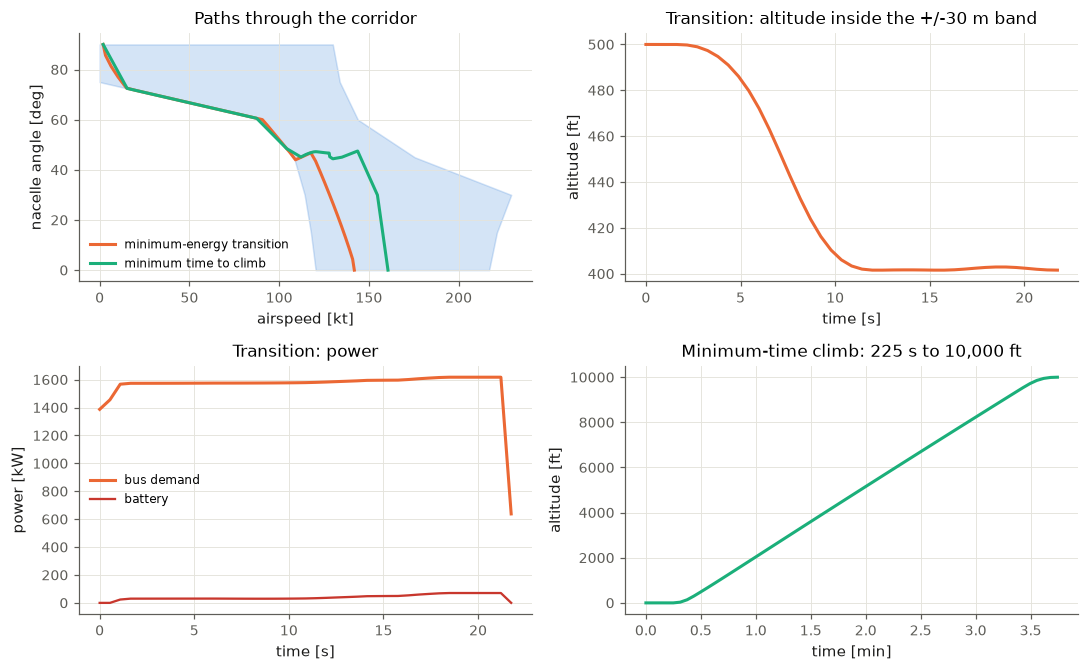

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6.2))
ax = axes[0, 0]
ax.fill_betweenx(list(corridor.tilts_deg), [v / u.knot for v in corridor.velocity_low_m_s], [v / u.knot for v in corridor.velocity_high_m_s],
                 color=blue, alpha=0.2)
for result, color in ((transition, orange), (climb, aqua)):
    ax.plot(result.velocity_m_s / u.knot, result.tilt_deg, color=color, lw=2, label=result.label)
ax.set(xlabel="airspeed [kt]", ylabel="nacelle angle [deg]", title="Paths through the corridor"); ax.legend(fontsize=8)
axes[0, 1].plot(transition.time_s, transition.altitude_m / u.foot, color=orange, lw=2)
axes[0, 1].set(xlabel="time [s]", ylabel="altitude [ft]", title="Transition: altitude inside the +/-30 m band")
axes[1, 0].plot(transition.time_s, transition.power_bus_W / 1e3, color=orange, lw=2, label="bus demand")
axes[1, 0].plot(transition.time_s, transition.power_battery_W / 1e3, color=red, lw=1.5, label="battery")
axes[1, 0].set(xlabel="time [s]", ylabel="power [kW]", title="Transition: power"); axes[1, 0].legend(fontsize=8)
axes[1, 1].plot(climb.time_s / 60, climb.altitude_m / u.foot, color=aqua, lw=2)
axes[1, 1].set(xlabel="time [min]", ylabel="altitude [ft]", title=f"Minimum-time climb: {climb.duration_s:.0f} s to 10,000 ft")
plt.tight_layout(); plt.show()

The transition rides the low-speed side of the corridor and descends inside its altitude band; the climb uses full turbine power plus the battery.
`examples/halo_trajectory_computed_corridor.py` records the finding that no *level, constant-acceleration* conversion exists inside the computed
corridor (the naive schedule needs a nose-down attitude beyond the trajectory model's limits).

## Summary

- Post-sizing analyses fly the fixed, numeric aircraft in their own Opti problems and never feed back into sizing.
- Trim: three equilibrium equations, four unknowns, least power, every limit a margin; the corridor makes airspeed a variable to find each bound and its
  binding limit.
- Trajectories: simultaneous (direct) collocation on AeroSandbox's point-mass dynamics, with the sizing's limits as path constraints and the corridor as
  airspeed bounds.

## Check yourself

<details><summary>1. Why does the trim have a free variable, and why spend it on power?</summary>

Four unknowns (thrust, attitude, tail deflection, disc tilt) against three equilibrium equations. Physically, the pilot (or flight control) can trade attitude against disc tilt; minimum rotor power is the natural schedule and makes the trim unique.
</details>

<details><summary>2. The corridor's high-speed side at 60° is set by edgewise advance ratio. How would that change the sizing?</summary>

It does not, unless a requirement is added. If a faster conversion is needed, a corridor requirement (a trim point at that speed and nacelle angle) would become a constraint of the sizing, and its multiplier would price it in rotor tip speed, hub limits or drive power.
</details>

In [8]:
check_summary()

2 of 2 checks passed
